In [11]:
import numpy as np
import matplotlib.pyplot as plt
import csv
from pathlib import Path
import mcstasscript as ms
from scipy.optimize import curve_fit  

/var/folders/td/xwsb6qn97jd2tvq057wsy3300000gn/T/ipykernel_19448/226122430.py:45: RuntimeWarning: Mean of empty slice
  lon_profile = np.nanmean(zoom_I, axis=0)
/var/folders/td/xwsb6qn97jd2tvq057wsy3300000gn/T/ipykernel_19448/226122430.py:46: RuntimeWarning: Mean of empty slice
  lat_profile = np.nanmean(zoom_I, axis=1)
/var/folders/td/xwsb6qn97jd2tvq057wsy3300000gn/T/ipykernel_19448/226122430.py:57: RuntimeWarning: Mean of empty slice
  mirrored_asym_vs_lat = np.nanmean(mirrored_asym, axis=1)


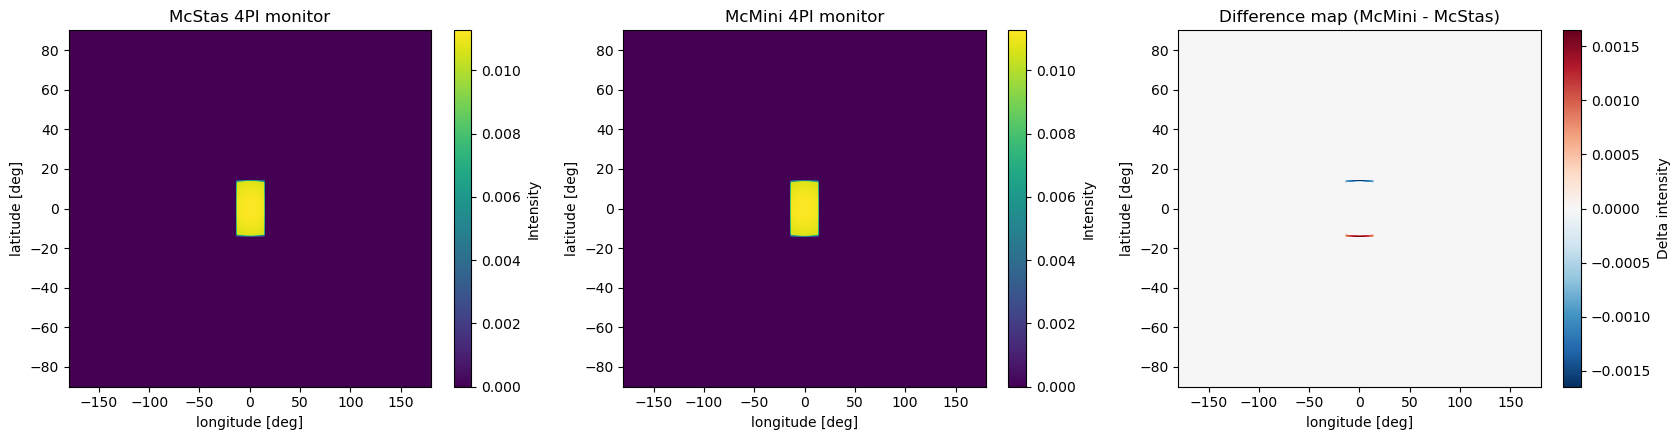

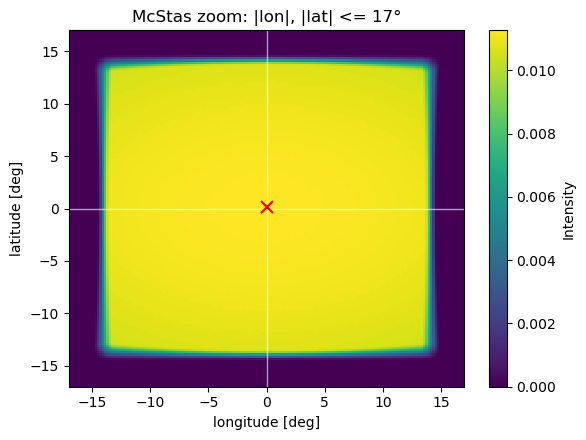

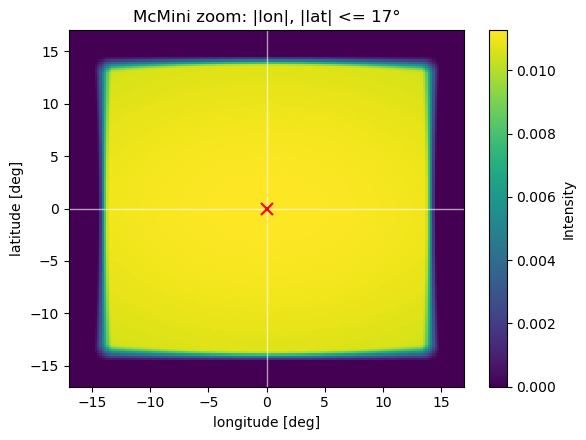

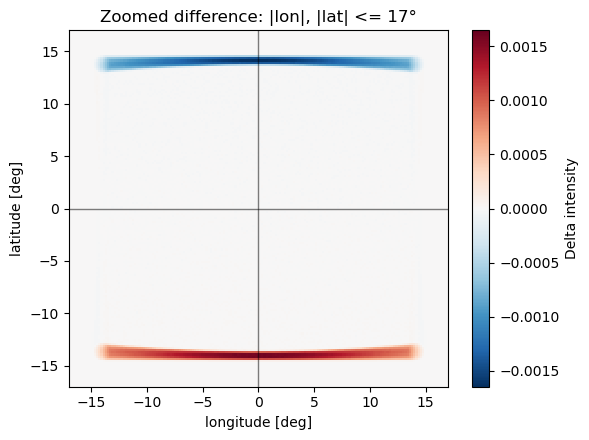

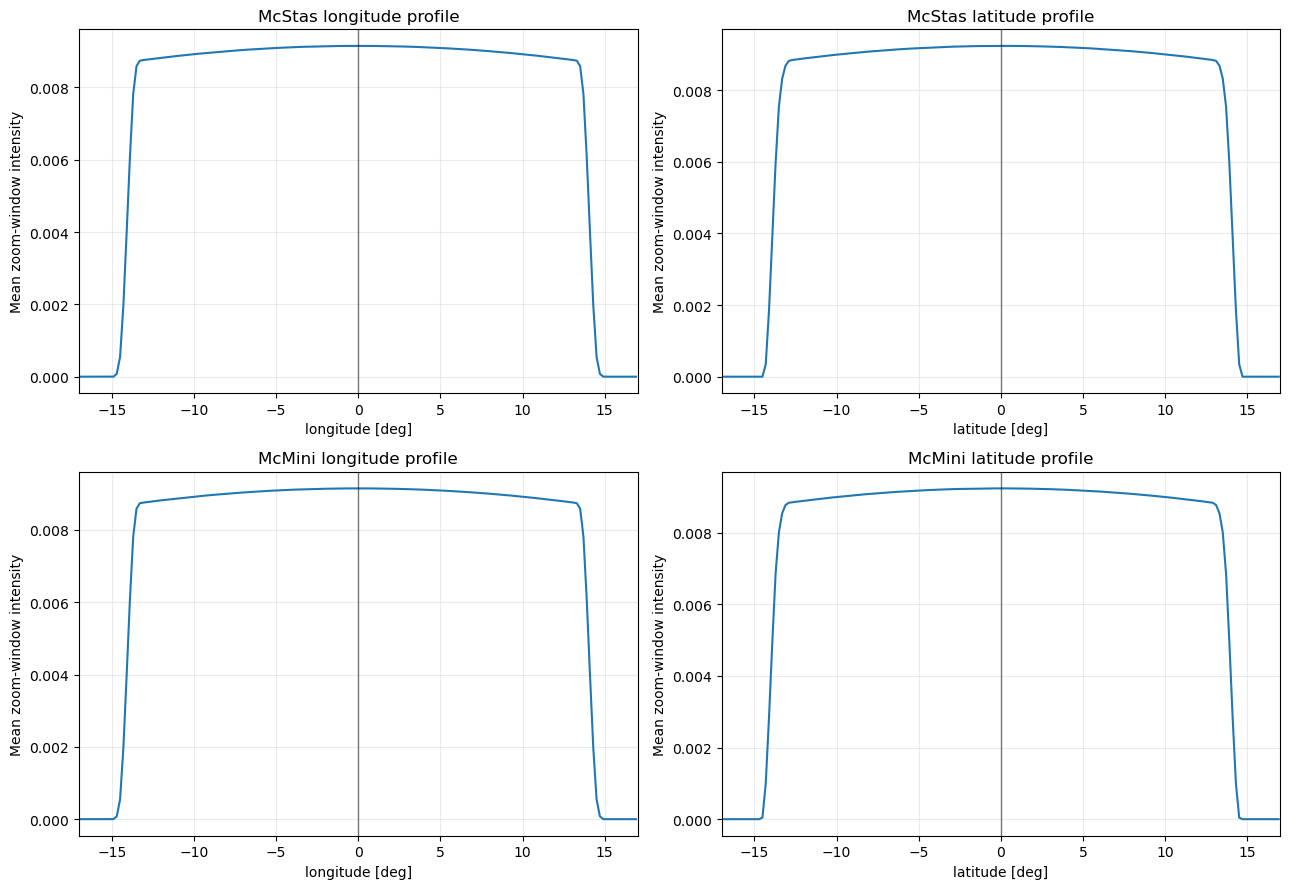

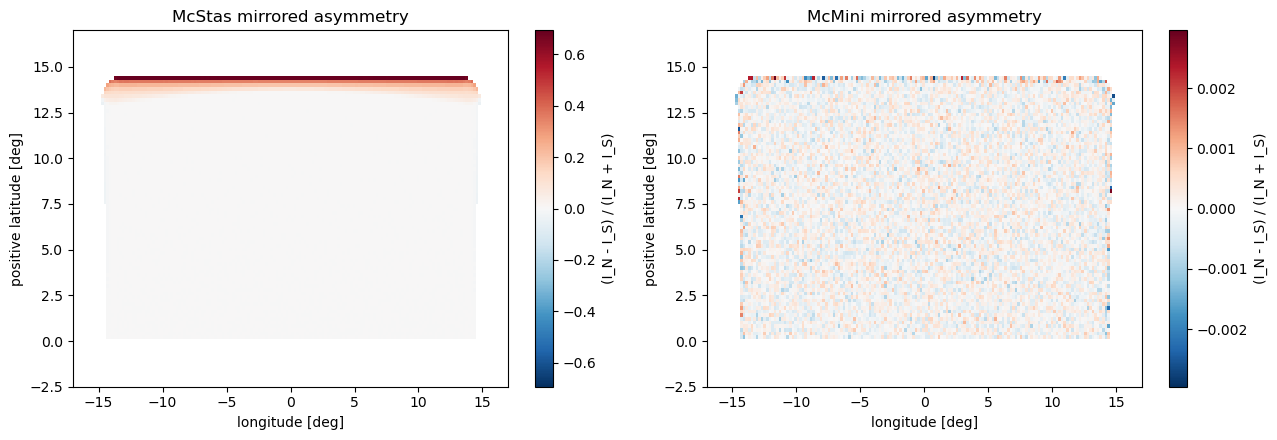

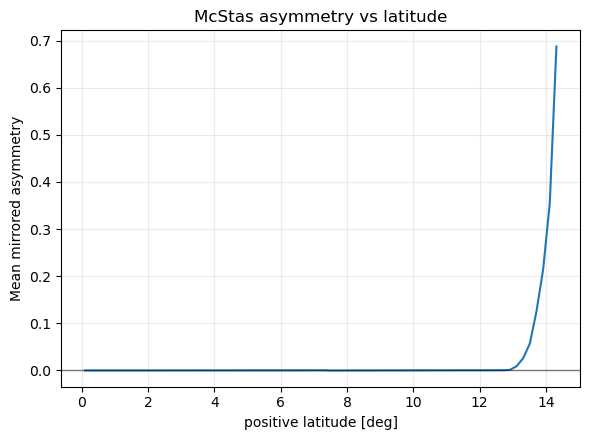

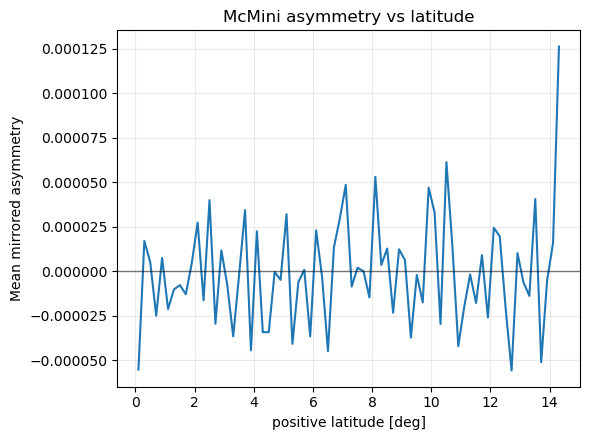

McStas
  Zoom-window north-south asymmetry: 7.303113e-03
  Zoom-window east-west asymmetry:   -4.047758e-06
  Zoom-window centroid longitude:    -3.371488e-05 deg
  Zoom-window centroid latitude:     1.001304e-01 deg
  High-signal threshold value:       1.126760e-03
  Mean mirrored asymmetry:           2.013888e-02
  Mean |mirrored asymmetry|:         2.058392e-02
McMini
  Zoom-window north-south asymmetry: -8.906887e-07
  Zoom-window east-west asymmetry:   -2.487758e-06
  Zoom-window centroid longitude:    -2.211907e-05 deg
  Zoom-window centroid latitude:     1.151968e-06 deg
  High-signal threshold value:       1.126636e-03
  Mean mirrored asymmetry:           -9.250531e-07
  Mean |mirrored asymmetry|:         2.727915e-04


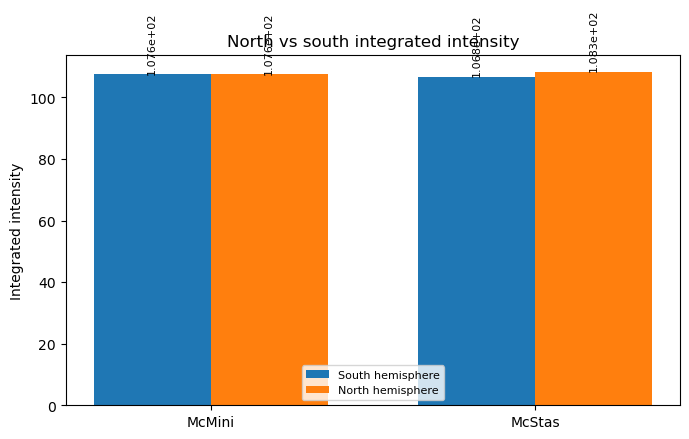

Integrated intensity summary
  McStas total: 2.1510448428e+02
  McStas north: 1.0833770831e+02
  McStas south: 1.0676677597e+02
  McStas (N-S)/(N+S): 7.303113e-03
  McMini total: 2.1510450802e+02
  McMini north: 1.0755215822e+02
  McMini south: 1.0755234981e+02
  McMini (N-S)/(N+S): -8.906887e-07


In [12]:
# 4PI monitor right after the source: McStas vs McMini
mcstas_mon = ms.load_data("/Users/christian/Documents/Study/bachelor_project/mcmini_verification/monitor_sphere_validation/HS_srcsimple_to_4pi_1e11")[0]  # adjust index if needed
mcstas_I = np.array(mcstas_mon.Intensity, copy=True)
mcstas_meta = mcstas_mon.metadata
if mcstas_I.shape == (mcstas_meta.dimension[0], mcstas_meta.dimension[1]):
    mcstas_I = mcstas_I.T

mcmini_path = Path("/Users/christian/Documents/Study/bachelor_project/mcmini_verification/monitor_sphere_validation/HS_srcsimple_to_4pi_1e11.csv")
mcmini_data = np.loadtxt(mcmini_path, delimiter=",", comments="#")
nx = int(np.max(mcmini_data[:, 0])) + 1
ny = int(np.max(mcmini_data[:, 1])) + 1
mcmini_I = mcmini_data[:, 2].reshape((ny, nx))

lon_min, lon_max, lat_min, lat_max = mcstas_meta.limits
extent_4pi = [lon_min, lon_max, lat_min, lat_max]
ny_4pi, nx_4pi = mcstas_I.shape
lon_centers_4pi = np.linspace(lon_min, lon_max, nx_4pi)
lat_centers_4pi = np.linspace(lat_min, lat_max, ny_4pi)
Lon4, Lat4 = np.meshgrid(lon_centers_4pi, lat_centers_4pi)

zoom_lon_deg = 17.0
zoom_lat_deg = 17.0
signal_fraction_threshold = 0.05
zoom_mask = (np.abs(Lon4) <= zoom_lon_deg) & (np.abs(Lat4) <= zoom_lat_deg)

def safe_asym(pos, neg):
    denom = pos + neg
    return (pos - neg) / denom if denom > 0 else np.nan


def analyze_map(I_map):
    zoom_I = np.where(zoom_mask, I_map, np.nan)

    north_sum = np.nansum(np.where((Lat4 > 0) & zoom_mask, I_map, np.nan))
    south_sum = np.nansum(np.where((Lat4 < 0) & zoom_mask, I_map, np.nan))
    east_sum = np.nansum(np.where((Lon4 > 0) & zoom_mask, I_map, np.nan))
    west_sum = np.nansum(np.where((Lon4 < 0) & zoom_mask, I_map, np.nan))
    ns_asym = safe_asym(north_sum, south_sum)
    ew_asym = safe_asym(east_sum, west_sum)

    total_zoom_I = np.nansum(zoom_I)
    lon_centroid = np.nansum(zoom_I * Lon4) / total_zoom_I
    lat_centroid = np.nansum(zoom_I * Lat4) / total_zoom_I

    lon_profile = np.nanmean(zoom_I, axis=0)
    lat_profile = np.nanmean(zoom_I, axis=1)

    lat_pos_mask = lat_centers_4pi > 0
    lat_pos = lat_centers_4pi[lat_pos_mask]
    north_I = I_map[lat_pos_mask, :]
    south_I = I_map[::-1, :][lat_pos_mask, :]
    sum_I = north_I + south_I
    diff_I = north_I - south_I
    signal_threshold = signal_fraction_threshold * np.nanmax(sum_I)
    high_signal_mask = sum_I > signal_threshold
    mirrored_asym = np.where(high_signal_mask, diff_I / np.where(sum_I > 0, sum_I, np.nan), np.nan)
    mirrored_asym_vs_lat = np.nanmean(mirrored_asym, axis=1)

    return {
        "zoom_I": zoom_I,
        "ns_asym": ns_asym,
        "ew_asym": ew_asym,
        "lon_centroid": lon_centroid,
        "lat_centroid": lat_centroid,
        "lon_profile": lon_profile,
        "lat_profile": lat_profile,
        "lat_pos": lat_pos,
        "mirrored_asym": mirrored_asym,
        "mirrored_asym_vs_lat": mirrored_asym_vs_lat,
        "signal_threshold": signal_threshold,
    }

mcstas_result = analyze_map(mcstas_I)
mcmini_result = analyze_map(mcmini_I)
diff_map = mcmini_I - mcstas_I
diff_zoom = np.where(zoom_mask, diff_map, np.nan)

vmax = max(np.nanmax(mcstas_I), np.nanmax(mcmini_I))
diff_absmax = np.nanmax(np.abs(diff_zoom))

fig, axs = plt.subplots(1, 3, figsize=(17, 4.5))
im0 = axs[0].imshow(mcstas_I, origin="lower", extent=extent_4pi, aspect="auto", interpolation="nearest", vmin=0, vmax=vmax)
axs[0].set_xlabel("longitude [deg]")
axs[0].set_ylabel("latitude [deg]")
axs[0].set_title("McStas 4PI monitor")
fig.colorbar(im0, ax=axs[0], label="Intensity")

im1 = axs[1].imshow(mcmini_I, origin="lower", extent=extent_4pi, aspect="auto", interpolation="nearest", vmin=0, vmax=vmax)
axs[1].set_xlabel("longitude [deg]")
axs[1].set_ylabel("latitude [deg]")
axs[1].set_title("McMini 4PI monitor")
fig.colorbar(im1, ax=axs[1], label="Intensity")

im2 = axs[2].imshow(diff_map, origin="lower", extent=extent_4pi, aspect="auto", interpolation="nearest", cmap="RdBu_r", vmin=-diff_absmax, vmax=diff_absmax)
axs[2].set_xlabel("longitude [deg]")
axs[2].set_ylabel("latitude [deg]")
axs[2].set_title("Difference map (McMini - McStas)")
fig.colorbar(im2, ax=axs[2], label="Delta intensity")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4.5))
im3 = ax.imshow(mcstas_I, origin="lower", extent=extent_4pi, aspect="auto", interpolation="nearest", vmin=0, vmax=vmax)
ax.set_xlim(-zoom_lon_deg, zoom_lon_deg)
ax.set_ylim(-zoom_lat_deg, zoom_lat_deg)
ax.axvline(0.0, color="w", lw=1.0, alpha=0.6)
ax.axhline(0.0, color="w", lw=1.0, alpha=0.6)
ax.plot(mcstas_result["lon_centroid"], mcstas_result["lat_centroid"], marker="x", color="r", ms=8, mew=1.5)
ax.set_xlabel("longitude [deg]")
ax.set_ylabel("latitude [deg]")
ax.set_title(f"McStas zoom: |lon|, |lat| <= {zoom_lon_deg:.0f}°")
fig.colorbar(im3, ax=ax, label="Intensity")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4.5))
im4 = ax.imshow(mcmini_I, origin="lower", extent=extent_4pi, aspect="auto", interpolation="nearest", vmin=0, vmax=vmax)
ax.set_xlim(-zoom_lon_deg, zoom_lon_deg)
ax.set_ylim(-zoom_lat_deg, zoom_lat_deg)
ax.axvline(0.0, color="w", lw=1.0, alpha=0.6)
ax.axhline(0.0, color="w", lw=1.0, alpha=0.6)
ax.plot(mcmini_result["lon_centroid"], mcmini_result["lat_centroid"], marker="x", color="r", ms=8, mew=1.5)
ax.set_xlabel("longitude [deg]")
ax.set_ylabel("latitude [deg]")
ax.set_title(f"McMini zoom: |lon|, |lat| <= {zoom_lon_deg:.0f}°")
fig.colorbar(im4, ax=ax, label="Intensity")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4.5))
im5 = ax.imshow(diff_map, origin="lower", extent=extent_4pi, aspect="auto", interpolation="nearest", cmap="RdBu_r", vmin=-diff_absmax, vmax=diff_absmax)
ax.set_xlim(-zoom_lon_deg, zoom_lon_deg)
ax.set_ylim(-zoom_lat_deg, zoom_lat_deg)
ax.axvline(0.0, color="k", lw=1.0, alpha=0.5)
ax.axhline(0.0, color="k", lw=1.0, alpha=0.5)
ax.set_xlabel("longitude [deg]")
ax.set_ylabel("latitude [deg]")
ax.set_title(f"Zoomed difference: |lon|, |lat| <= {zoom_lon_deg:.0f}°")
fig.colorbar(im5, ax=ax, label="Delta intensity")

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(2, 2, figsize=(13, 9))
axs[0, 0].plot(lon_centers_4pi, mcstas_result["lon_profile"], label="McStas")
axs[0, 0].axvline(0.0, color="k", lw=1.0, alpha=0.5)
axs[0, 0].set_xlim(-zoom_lon_deg, zoom_lon_deg)
axs[0, 0].set_xlabel("longitude [deg]")
axs[0, 0].set_ylabel("Mean zoom-window intensity")
axs[0, 0].set_title("McStas longitude profile")
axs[0, 0].grid(alpha=0.25)

axs[0, 1].plot(lat_centers_4pi, mcstas_result["lat_profile"], label="McStas")
axs[0, 1].axvline(0.0, color="k", lw=1.0, alpha=0.5)
axs[0, 1].set_xlim(-zoom_lat_deg, zoom_lat_deg)
axs[0, 1].set_xlabel("latitude [deg]")
axs[0, 1].set_ylabel("Mean zoom-window intensity")
axs[0, 1].set_title("McStas latitude profile")
axs[0, 1].grid(alpha=0.25)

axs[1, 0].plot(lon_centers_4pi, mcmini_result["lon_profile"], label="McMini")
axs[1, 0].axvline(0.0, color="k", lw=1.0, alpha=0.5)
axs[1, 0].set_xlim(-zoom_lon_deg, zoom_lon_deg)
axs[1, 0].set_xlabel("longitude [deg]")
axs[1, 0].set_ylabel("Mean zoom-window intensity")
axs[1, 0].set_title("McMini longitude profile")
axs[1, 0].grid(alpha=0.25)

axs[1, 1].plot(lat_centers_4pi, mcmini_result["lat_profile"], label="McMini")
axs[1, 1].axvline(0.0, color="k", lw=1.0, alpha=0.5)
axs[1, 1].set_xlim(-zoom_lat_deg, zoom_lat_deg)
axs[1, 1].set_xlabel("latitude [deg]")
axs[1, 1].set_ylabel("Mean zoom-window intensity")
axs[1, 1].set_title("McMini latitude profile")
axs[1, 1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))
mcstas_absmax = np.nanmax(np.abs(mcstas_result["mirrored_asym"]))
mcmini_absmax = np.nanmax(np.abs(mcmini_result["mirrored_asym"]))

im6 = axs[0].imshow(
    mcstas_result["mirrored_asym"],
    origin="lower",
    extent=[lon_centers_4pi[0], lon_centers_4pi[-1], mcstas_result["lat_pos"][0], mcstas_result["lat_pos"][-1]],
    aspect="auto",
    interpolation="nearest",
    cmap="RdBu_r",
    vmin=-mcstas_absmax,
    vmax=mcstas_absmax,
)
axs[0].set_xlim(-zoom_lon_deg, zoom_lon_deg)
axs[0].set_ylim(-2.5, zoom_lat_deg)
axs[0].set_xlabel("longitude [deg]")
axs[0].set_ylabel("positive latitude [deg]")
axs[0].set_title("McStas mirrored asymmetry")
fig.colorbar(im6, ax=axs[0], label="(I_N - I_S) / (I_N + I_S)")

im7 = axs[1].imshow(
    mcmini_result["mirrored_asym"],
    origin="lower",
    extent=[lon_centers_4pi[0], lon_centers_4pi[-1], mcmini_result["lat_pos"][0], mcmini_result["lat_pos"][-1]],
    aspect="auto",
    interpolation="nearest",
    cmap="RdBu_r",
    vmin=-mcmini_absmax,
    vmax=mcmini_absmax,
)
axs[1].set_xlim(-zoom_lon_deg, zoom_lon_deg)
axs[1].set_ylim(-2.5, zoom_lat_deg)
axs[1].set_xlabel("longitude [deg]")
axs[1].set_ylabel("positive latitude [deg]")
axs[1].set_title("McMini mirrored asymmetry")
fig.colorbar(im7, ax=axs[1], label="(I_N - I_S) / (I_N + I_S)")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(mcstas_result["lat_pos"], mcstas_result["mirrored_asym_vs_lat"], lw=1.5)
ax.axhline(0.0, color="k", lw=1.0, alpha=0.5)
ax.set_xlabel("positive latitude [deg]")
ax.set_ylabel("Mean mirrored asymmetry")
ax.set_title("McStas asymmetry vs latitude")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(mcmini_result["lat_pos"], mcmini_result["mirrored_asym_vs_lat"], lw=1.5)
ax.axhline(0.0, color="k", lw=1.0, alpha=0.5)
ax.set_xlabel("positive latitude [deg]")
ax.set_ylabel("Mean mirrored asymmetry")
ax.set_title("McMini asymmetry vs latitude")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

for label, result in [("McStas", mcstas_result), ("McMini", mcmini_result)]:
    print(label)
    print(f"  Zoom-window north-south asymmetry: {result['ns_asym']:.6e}")
    print(f"  Zoom-window east-west asymmetry:   {result['ew_asym']:.6e}")
    print(f"  Zoom-window centroid longitude:    {result['lon_centroid']:.6e} deg")
    print(f"  Zoom-window centroid latitude:     {result['lat_centroid']:.6e} deg")
    print(f"  High-signal threshold value:       {result['signal_threshold']:.6e}")
    print(f"  Mean mirrored asymmetry:           {np.nanmean(result['mirrored_asym']):.6e}")
    print(f"  Mean |mirrored asymmetry|:         {np.nanmean(np.abs(result['mirrored_asym'])):.6e}")

north_mask = Lat4 > 0
south_mask = Lat4 < 0
mcstas_total = np.nansum(mcstas_I)
mcstas_north = np.nansum(np.where(north_mask, mcstas_I, np.nan))
mcstas_south = np.nansum(np.where(south_mask, mcstas_I, np.nan))
mcmini_total = np.nansum(mcmini_I)
mcmini_north = np.nansum(np.where(north_mask, mcmini_I, np.nan))
mcmini_south = np.nansum(np.where(south_mask, mcmini_I, np.nan))

fig, ax = plt.subplots(figsize=(7, 4.5))
labels = ["McMini", "McStas"]
north_vals = [mcmini_north, mcstas_north]
south_vals = [mcmini_south, mcstas_south]
x = np.arange(len(labels))
width = 0.36
south_bars = ax.bar(x - width/2, south_vals, width=width, label="South hemisphere")
north_bars = ax.bar(x + width/2, north_vals, width=width, label="North hemisphere")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Integrated intensity")
ax.set_title("North vs south integrated intensity")
ax.legend(prop={'size': 8}, loc="lower center")
for bars in (south_bars, north_bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.3e}",
            ha="center",
            va="bottom",
            rotation=90,
            fontsize=8,
        )
plt.tight_layout()
plt.show()

print("Integrated intensity summary")
print(f"  McStas total: {mcstas_total:.10e}")
print(f"  McStas north: {mcstas_north:.10e}")
print(f"  McStas south: {mcstas_south:.10e}")
print(f"  McStas (N-S)/(N+S): {(mcstas_north - mcstas_south)/(mcstas_north + mcstas_south):.6e}")
print(f"  McMini total: {mcmini_total:.10e}")
print(f"  McMini north: {mcmini_north:.10e}")
print(f"  McMini south: {mcmini_south:.10e}")
print(f"  McMini (N-S)/(N+S): {(mcmini_north - mcmini_south)/(mcmini_north + mcmini_south):.6e}")





/var/folders/td/xwsb6qn97jd2tvq057wsy3300000gn/T/ipykernel_19448/637734187.py:45: RuntimeWarning: Mean of empty slice
  lon_profile = np.nanmean(zoom_I, axis=0)
/var/folders/td/xwsb6qn97jd2tvq057wsy3300000gn/T/ipykernel_19448/637734187.py:46: RuntimeWarning: Mean of empty slice
  lat_profile = np.nanmean(zoom_I, axis=1)
/var/folders/td/xwsb6qn97jd2tvq057wsy3300000gn/T/ipykernel_19448/637734187.py:57: RuntimeWarning: Mean of empty slice
  mirrored_asym_vs_lat = np.nanmean(mirrored_asym, axis=1)


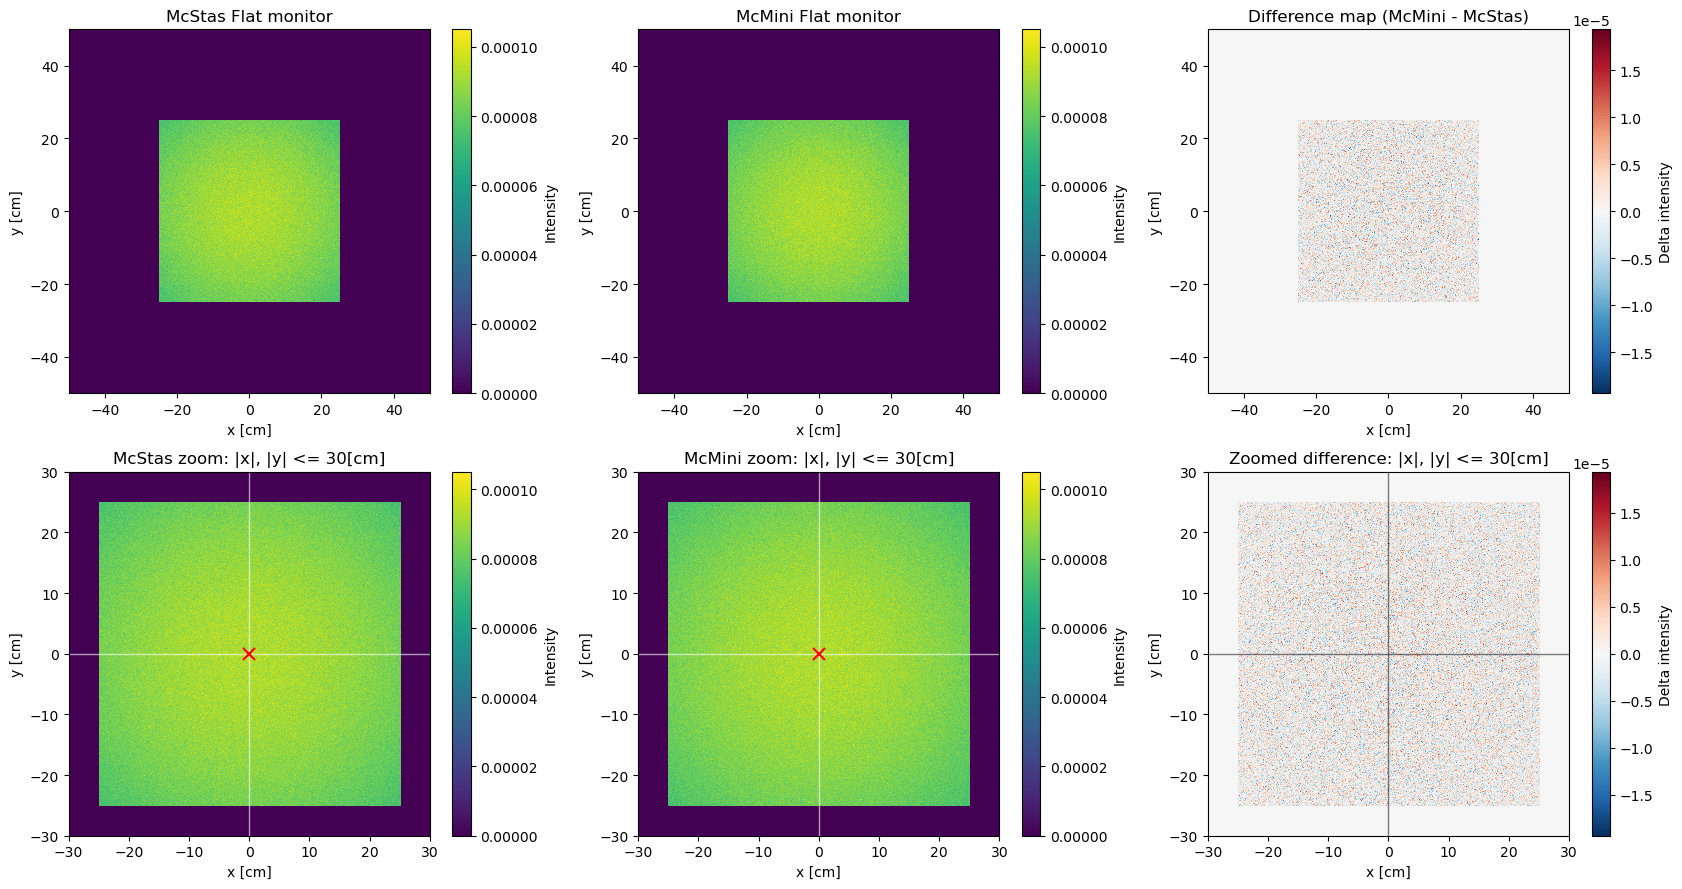

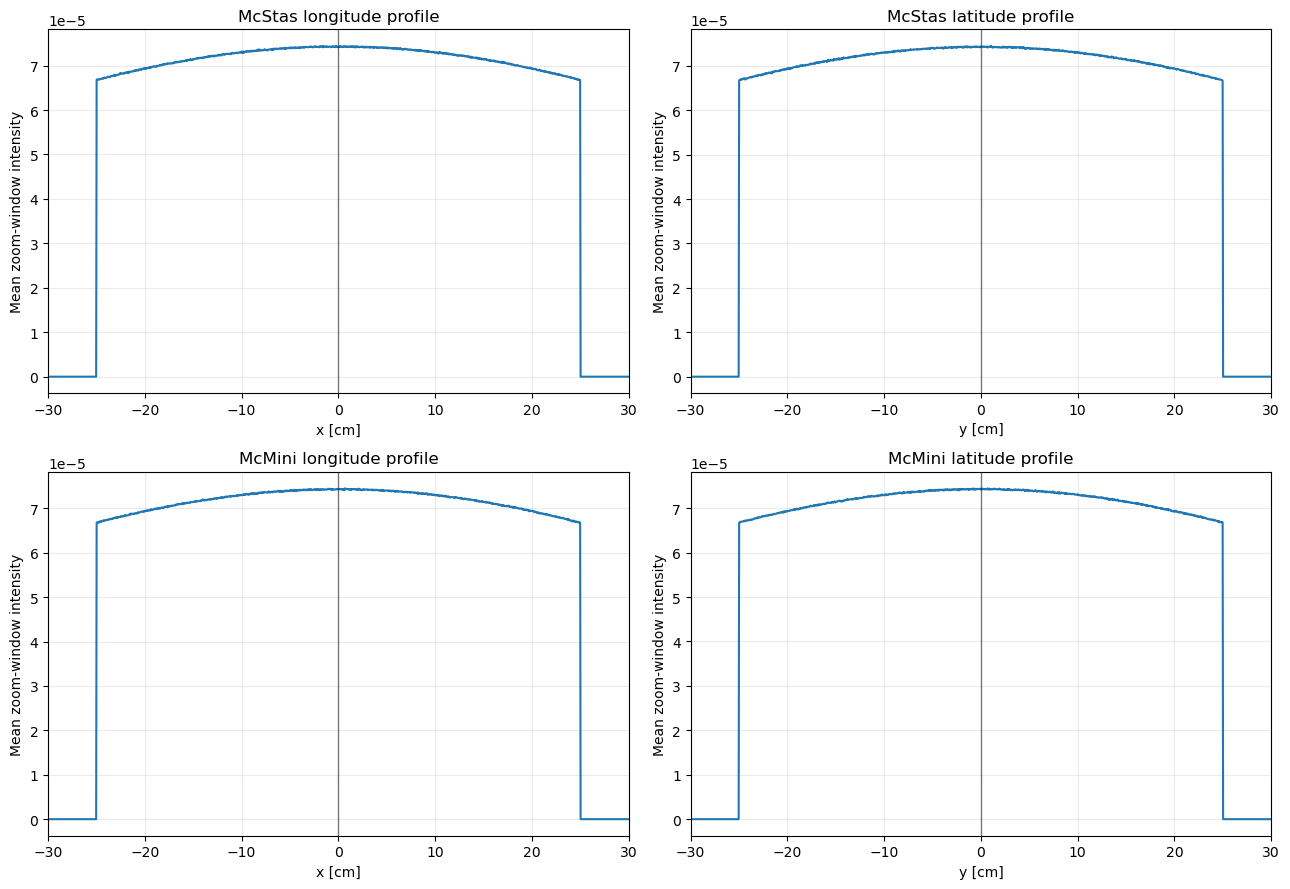

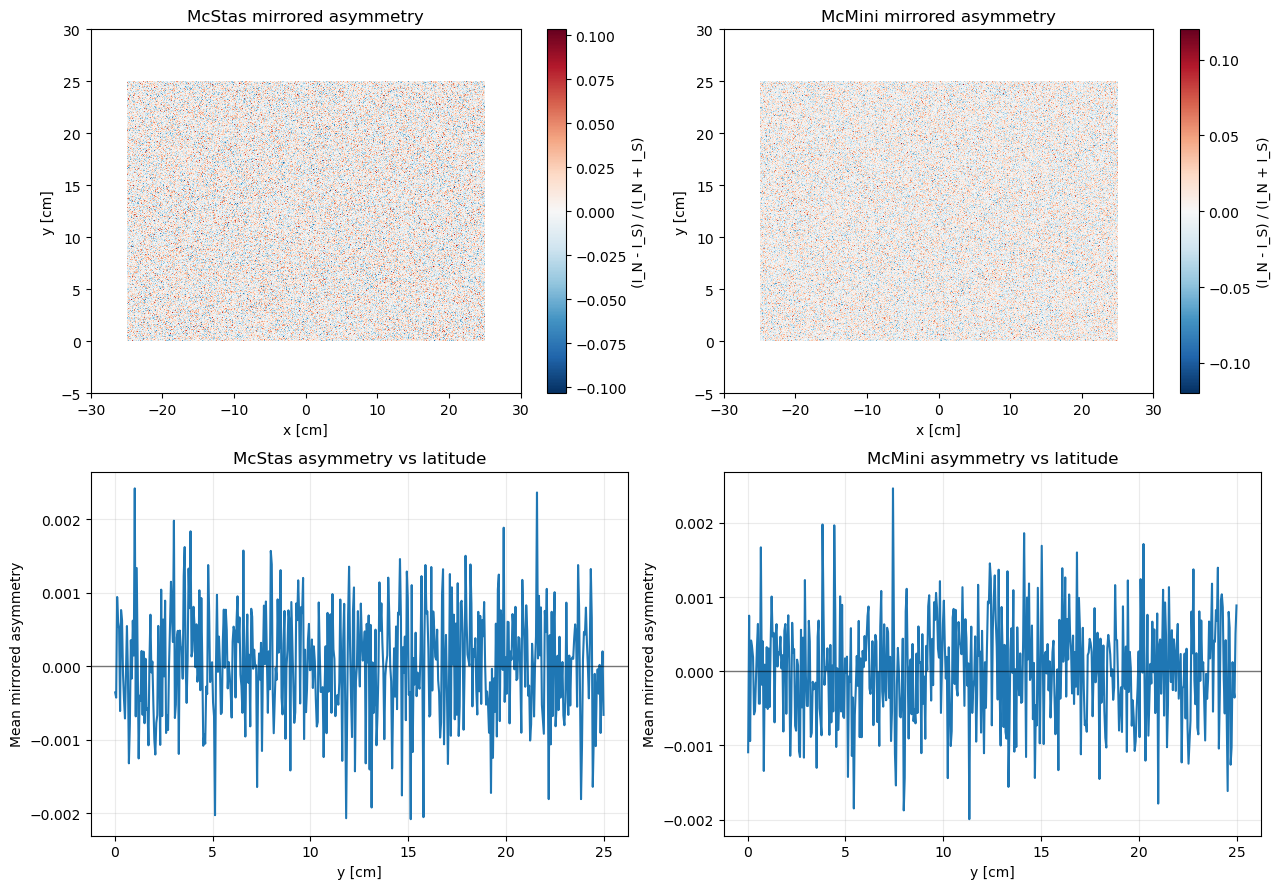

McStas
  Zoom-window north-south asymmetry: 3.079772e-05
  Zoom-window east-west asymmetry:   -9.871079e-06
  Zoom-window centroid longitude:    -2.756109e-04 deg
  Zoom-window centroid latitude:     2.804756e-04 deg
  High-signal threshold value:       1.008433e-05
  Mean mirrored asymmetry:           2.941289e-05
  Mean |mirrored asymmetry|:         1.796462e-02
McMini
  Zoom-window north-south asymmetry: 9.810333e-06
  Zoom-window east-west asymmetry:   2.479402e-05
  Zoom-window centroid longitude:    -1.296813e-04 deg
  Zoom-window centroid latitude:     2.584248e-04 deg
  High-signal threshold value:       1.009259e-05
  Mean mirrored asymmetry:           8.619456e-06
  Mean |mirrored asymmetry|:         1.794831e-02


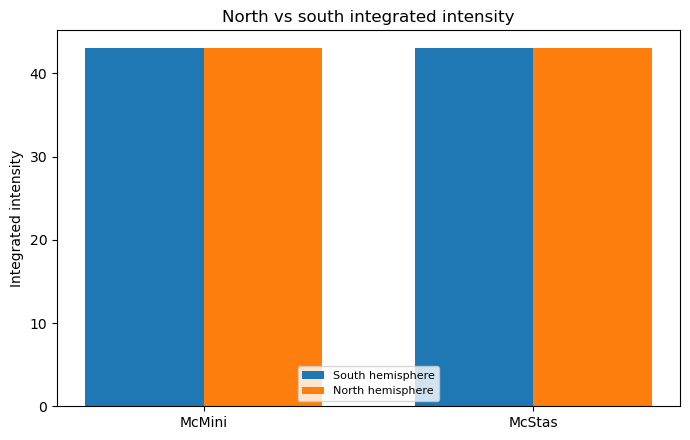

Integrated intensity summary
  McStas total: 8.604235e+01
  McStas north: 4.302250e+01
  McStas south: 4.301985e+01
  McStas (N-S)/(N+S): 3.079772e-05
  McMini total: 8.604149e+01
  McMini north: 4.302117e+01
  McMini south: 4.302032e+01
  McMini (N-S)/(N+S): 9.810333e-06


In [13]:
# 4PI monitor right after the source: McStas vs McMini
mcstas_mon = ms.load_data("/Users/christian/Documents/Study/bachelor_project/mcmini_verification/source_simple_verification/source_to_flat_monitor")[0]  # adjust index if needed
mcstas_I = np.array(mcstas_mon.Intensity, copy=True)
mcstas_meta = mcstas_mon.metadata
if mcstas_I.shape == (mcstas_meta.dimension[0], mcstas_meta.dimension[1]):
    mcstas_I = mcstas_I.T

mcmini_path = Path("/Users/christian/Documents/Study/bachelor_project/mcmini_verification/source_simple_verification/source_to_flat_monitor.csv")
mcmini_data = np.loadtxt(mcmini_path, delimiter=",", comments="#")
nx = int(np.max(mcmini_data[:, 0])) + 1
ny = int(np.max(mcmini_data[:, 1])) + 1
mcmini_I = mcmini_data[:, 2].reshape((ny, nx))

lon_min, lon_max, lat_min, lat_max = mcstas_meta.limits
extent_4pi = [lon_min, lon_max, lat_min, lat_max]
ny_4pi, nx_4pi = mcstas_I.shape
lon_centers_4pi = np.linspace(lon_min, lon_max, nx_4pi)
lat_centers_4pi = np.linspace(lat_min, lat_max, ny_4pi)
Lon4, Lat4 = np.meshgrid(lon_centers_4pi, lat_centers_4pi)

zoom_lon_deg = 30.0
zoom_lat_deg = 30.0
signal_fraction_threshold = 0.05
zoom_mask = (np.abs(Lon4) <= zoom_lon_deg) & (np.abs(Lat4) <= zoom_lat_deg)

def safe_asym(pos, neg):
    denom = pos + neg
    return (pos - neg) / denom if denom > 0 else np.nan


def analyze_map(I_map):
    zoom_I = np.where(zoom_mask, I_map, np.nan)

    north_sum = np.nansum(np.where((Lat4 > 0) & zoom_mask, I_map, np.nan))
    south_sum = np.nansum(np.where((Lat4 < 0) & zoom_mask, I_map, np.nan))
    east_sum = np.nansum(np.where((Lon4 > 0) & zoom_mask, I_map, np.nan))
    west_sum = np.nansum(np.where((Lon4 < 0) & zoom_mask, I_map, np.nan))
    ns_asym = safe_asym(north_sum, south_sum)
    ew_asym = safe_asym(east_sum, west_sum)

    total_zoom_I = np.nansum(zoom_I)
    lon_centroid = np.nansum(zoom_I * Lon4) / total_zoom_I
    lat_centroid = np.nansum(zoom_I * Lat4) / total_zoom_I

    lon_profile = np.nanmean(zoom_I, axis=0)
    lat_profile = np.nanmean(zoom_I, axis=1)

    lat_pos_mask = lat_centers_4pi > 0
    lat_pos = lat_centers_4pi[lat_pos_mask]
    north_I = I_map[lat_pos_mask, :]
    south_I = I_map[::-1, :][lat_pos_mask, :]
    sum_I = north_I + south_I
    diff_I = north_I - south_I
    signal_threshold = signal_fraction_threshold * np.nanmax(sum_I)
    high_signal_mask = sum_I > signal_threshold
    mirrored_asym = np.where(high_signal_mask, diff_I / np.where(sum_I > 0, sum_I, np.nan), np.nan)
    mirrored_asym_vs_lat = np.nanmean(mirrored_asym, axis=1)

    return {
        "zoom_I": zoom_I,
        "ns_asym": ns_asym,
        "ew_asym": ew_asym,
        "lon_centroid": lon_centroid,
        "lat_centroid": lat_centroid,
        "lon_profile": lon_profile,
        "lat_profile": lat_profile,
        "lat_pos": lat_pos,
        "mirrored_asym": mirrored_asym,
        "mirrored_asym_vs_lat": mirrored_asym_vs_lat,
        "signal_threshold": signal_threshold,
    }

mcstas_result = analyze_map(mcstas_I)
mcmini_result = analyze_map(mcmini_I)
diff_map = mcmini_I - mcstas_I
diff_zoom = np.where(zoom_mask, diff_map, np.nan)

vmax = max(np.nanmax(mcstas_I), np.nanmax(mcmini_I))
diff_absmax = np.nanmax(np.abs(diff_zoom))

fig, axs = plt.subplots(2, 3, figsize=(17, 9))
im0 = axs[0, 0].imshow(mcstas_I, origin="lower", extent=extent_4pi, aspect="auto", interpolation="nearest", vmin=0, vmax=vmax)
axs[0, 0].set_xlabel("x [cm]")
axs[0, 0].set_ylabel("y [cm]")
axs[0, 0].set_title("McStas Flat monitor")
fig.colorbar(im0, ax=axs[0, 0], label="Intensity")

im1 = axs[0, 1].imshow(mcmini_I, origin="lower", extent=extent_4pi, aspect="auto", interpolation="nearest", vmin=0, vmax=vmax)
axs[0, 1].set_xlabel("x [cm]")
axs[0, 1].set_ylabel("y [cm]")
axs[0, 1].set_title("McMini Flat monitor")
fig.colorbar(im1, ax=axs[0, 1], label="Intensity")

im2 = axs[0, 2].imshow(diff_map, origin="lower", extent=extent_4pi, aspect="auto", interpolation="nearest", cmap="RdBu_r", vmin=-diff_absmax, vmax=diff_absmax)
axs[0, 2].set_xlabel("x [cm]")
axs[0, 2].set_ylabel("y [cm]")
axs[0, 2].set_title("Difference map (McMini - McStas)")
fig.colorbar(im2, ax=axs[0, 2], label="Delta intensity")

im3 = axs[1, 0].imshow(mcstas_I, origin="lower", extent=extent_4pi, aspect="auto", interpolation="nearest", vmin=0, vmax=vmax)
axs[1, 0].set_xlim(-zoom_lon_deg, zoom_lon_deg)
axs[1, 0].set_ylim(-zoom_lat_deg, zoom_lat_deg)
axs[1, 0].axvline(0.0, color="w", lw=1.0, alpha=0.6)
axs[1, 0].axhline(0.0, color="w", lw=1.0, alpha=0.6)
axs[1, 0].plot(mcstas_result["lon_centroid"], mcstas_result["lat_centroid"], marker="x", color="r", ms=8, mew=1.5)
axs[1, 0].set_xlabel("x [cm]")
axs[1, 0].set_ylabel("y [cm]")
axs[1, 0].set_title(f"McStas zoom: |x|, |y| <= {zoom_lon_deg:.0f}[cm]")
fig.colorbar(im3, ax=axs[1, 0], label="Intensity")

im4 = axs[1, 1].imshow(mcmini_I, origin="lower", extent=extent_4pi, aspect="auto", interpolation="nearest", vmin=0, vmax=vmax)
axs[1, 1].set_xlim(-zoom_lon_deg, zoom_lon_deg)
axs[1, 1].set_ylim(-zoom_lat_deg, zoom_lat_deg)
axs[1, 1].axvline(0.0, color="w", lw=1.0, alpha=0.6)
axs[1, 1].axhline(0.0, color="w", lw=1.0, alpha=0.6)
axs[1, 1].plot(mcmini_result["lon_centroid"], mcmini_result["lat_centroid"], marker="x", color="r", ms=8, mew=1.5)
axs[1, 1].set_xlabel("x [cm]")
axs[1, 1].set_ylabel("y [cm]")
axs[1, 1].set_title(f"McMini zoom: |x|, |y| <= {zoom_lon_deg:.0f}[cm]")
fig.colorbar(im4, ax=axs[1, 1], label="Intensity")

im5 = axs[1, 2].imshow(diff_map, origin="lower", extent=extent_4pi, aspect="auto", interpolation="nearest", cmap="RdBu_r", vmin=-diff_absmax, vmax=diff_absmax)
axs[1, 2].set_xlim(-zoom_lon_deg, zoom_lon_deg)
axs[1, 2].set_ylim(-zoom_lat_deg, zoom_lat_deg)
axs[1, 2].axvline(0.0, color="k", lw=1.0, alpha=0.5)
axs[1, 2].axhline(0.0, color="k", lw=1.0, alpha=0.5)
axs[1, 2].set_xlabel("x [cm]")
axs[1, 2].set_ylabel("y [cm]")
axs[1, 2].set_title(f"Zoomed difference: |x|, |y| <= {zoom_lon_deg:.0f}[cm]")
fig.colorbar(im5, ax=axs[1, 2], label="Delta intensity")

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(2, 2, figsize=(13, 9))
axs[0, 0].plot(lon_centers_4pi, mcstas_result["lon_profile"], label="McStas")
axs[0, 0].axvline(0.0, color="k", lw=1.0, alpha=0.5)
axs[0, 0].set_xlim(-zoom_lon_deg, zoom_lon_deg)
axs[0, 0].set_xlabel("x [cm]")
axs[0, 0].set_ylabel("Mean zoom-window intensity")
axs[0, 0].set_title("McStas longitude profile")
axs[0, 0].grid(alpha=0.25)

axs[0, 1].plot(lat_centers_4pi, mcstas_result["lat_profile"], label="McStas")
axs[0, 1].axvline(0.0, color="k", lw=1.0, alpha=0.5)
axs[0, 1].set_xlim(-zoom_lat_deg, zoom_lat_deg)
axs[0, 1].set_xlabel("y [cm]")
axs[0, 1].set_ylabel("Mean zoom-window intensity")
axs[0, 1].set_title("McStas latitude profile")
axs[0, 1].grid(alpha=0.25)

axs[1, 0].plot(lon_centers_4pi, mcmini_result["lon_profile"], label="McMini")
axs[1, 0].axvline(0.0, color="k", lw=1.0, alpha=0.5)
axs[1, 0].set_xlim(-zoom_lon_deg, zoom_lon_deg)
axs[1, 0].set_xlabel("x [cm]")
axs[1, 0].set_ylabel("Mean zoom-window intensity")
axs[1, 0].set_title("McMini longitude profile")
axs[1, 0].grid(alpha=0.25)

axs[1, 1].plot(lat_centers_4pi, mcmini_result["lat_profile"], label="McMini")
axs[1, 1].axvline(0.0, color="k", lw=1.0, alpha=0.5)
axs[1, 1].set_xlim(-zoom_lat_deg, zoom_lat_deg)
axs[1, 1].set_xlabel("y [cm]")
axs[1, 1].set_ylabel("Mean zoom-window intensity")
axs[1, 1].set_title("McMini latitude profile")
axs[1, 1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(2, 2, figsize=(13, 9))
mcstas_absmax = np.nanmax(np.abs(mcstas_result["mirrored_asym"]))
mcmini_absmax = np.nanmax(np.abs(mcmini_result["mirrored_asym"]))

im6 = axs[0, 0].imshow(
    mcstas_result["mirrored_asym"],
    origin="lower",
    extent=[lon_centers_4pi[0], lon_centers_4pi[-1], mcstas_result["lat_pos"][0], mcstas_result["lat_pos"][-1]],
    aspect="auto",
    interpolation="nearest",
    cmap="RdBu_r",
    vmin=-mcstas_absmax,
    vmax=mcstas_absmax,
)
axs[0, 0].set_xlim(-zoom_lon_deg, zoom_lon_deg)
axs[0, 0].set_ylim(-5, zoom_lat_deg)
axs[0, 0].set_xlabel("x [cm]")
axs[0, 0].set_ylabel("y [cm]")
axs[0, 0].set_title("McStas mirrored asymmetry")
fig.colorbar(im6, ax=axs[0, 0], label="(I_N - I_S) / (I_N + I_S)")

im7 = axs[0, 1].imshow(
    mcmini_result["mirrored_asym"],
    origin="lower",
    extent=[lon_centers_4pi[0], lon_centers_4pi[-1], mcmini_result["lat_pos"][0], mcmini_result["lat_pos"][-1]],
    aspect="auto",
    interpolation="nearest",
    cmap="RdBu_r",
    vmin=-mcmini_absmax,
    vmax=mcmini_absmax,
)
axs[0, 1].set_xlim(-zoom_lon_deg, zoom_lon_deg)
axs[0, 1].set_ylim(-5, zoom_lat_deg)
axs[0, 1].set_xlabel("x [cm]")
axs[0, 1].set_ylabel("y [cm]")
axs[0, 1].set_title("McMini mirrored asymmetry")
fig.colorbar(im7, ax=axs[0, 1], label="(I_N - I_S) / (I_N + I_S)")

axs[1, 0].plot(mcstas_result["lat_pos"], mcstas_result["mirrored_asym_vs_lat"], lw=1.5)
axs[1, 0].axhline(0.0, color="k", lw=1.0, alpha=0.5)
axs[1, 0].set_xlabel("y [cm]")
axs[1, 0].set_ylabel("Mean mirrored asymmetry")
axs[1, 0].set_title("McStas asymmetry vs latitude")
axs[1, 0].grid(alpha=0.25)

axs[1, 1].plot(mcmini_result["lat_pos"], mcmini_result["mirrored_asym_vs_lat"], lw=1.5)
axs[1, 1].axhline(0.0, color="k", lw=1.0, alpha=0.5)
axs[1, 1].set_xlabel("y [cm]")
axs[1, 1].set_ylabel("Mean mirrored asymmetry")
axs[1, 1].set_title("McMini asymmetry vs latitude")
axs[1, 1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

for label, result in [("McStas", mcstas_result), ("McMini", mcmini_result)]:
    print(label)
    print(f"  Zoom-window north-south asymmetry: {result['ns_asym']:.6e}")
    print(f"  Zoom-window east-west asymmetry:   {result['ew_asym']:.6e}")
    print(f"  Zoom-window centroid longitude:    {result['lon_centroid']:.6e} deg")
    print(f"  Zoom-window centroid latitude:     {result['lat_centroid']:.6e} deg")
    print(f"  High-signal threshold value:       {result['signal_threshold']:.6e}")
    print(f"  Mean mirrored asymmetry:           {np.nanmean(result['mirrored_asym']):.6e}")
    print(f"  Mean |mirrored asymmetry|:         {np.nanmean(np.abs(result['mirrored_asym'])):.6e}")

north_mask = Lat4 > 0
south_mask = Lat4 < 0
mcstas_total = np.nansum(mcstas_I)
mcstas_north = np.nansum(np.where(north_mask, mcstas_I, np.nan))
mcstas_south = np.nansum(np.where(south_mask, mcstas_I, np.nan))
mcmini_total = np.nansum(mcmini_I)
mcmini_north = np.nansum(np.where(north_mask, mcmini_I, np.nan))
mcmini_south = np.nansum(np.where(south_mask, mcmini_I, np.nan))

fig, ax = plt.subplots(figsize=(7, 4.5))
labels = ["McMini", "McStas"]
north_vals = [mcmini_north, mcstas_north]
south_vals = [mcmini_south, mcstas_south]
x = np.arange(len(labels))
width = 0.36
ax.bar(x - width/2, south_vals, width=width, label="South hemisphere")
ax.bar(x + width/2, north_vals, width=width, label="North hemisphere")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Integrated intensity")
ax.set_title("North vs south integrated intensity")
ax.legend(prop={'size': 8}, loc="lower center")
plt.tight_layout()
plt.show()

print("Integrated intensity summary")
print(f"  McStas total: {mcstas_total:.6e}")
print(f"  McStas north: {mcstas_north:.6e}")
print(f"  McStas south: {mcstas_south:.6e}")
print(f"  McStas (N-S)/(N+S): {(mcstas_north - mcstas_south)/(mcstas_north + mcstas_south):.6e}")
print(f"  McMini total: {mcmini_total:.6e}")
print(f"  McMini north: {mcmini_north:.6e}")
print(f"  McMini south: {mcmini_south:.6e}")
print(f"  McMini (N-S)/(N+S): {(mcmini_north - mcmini_south)/(mcmini_north + mcmini_south):.6e}")



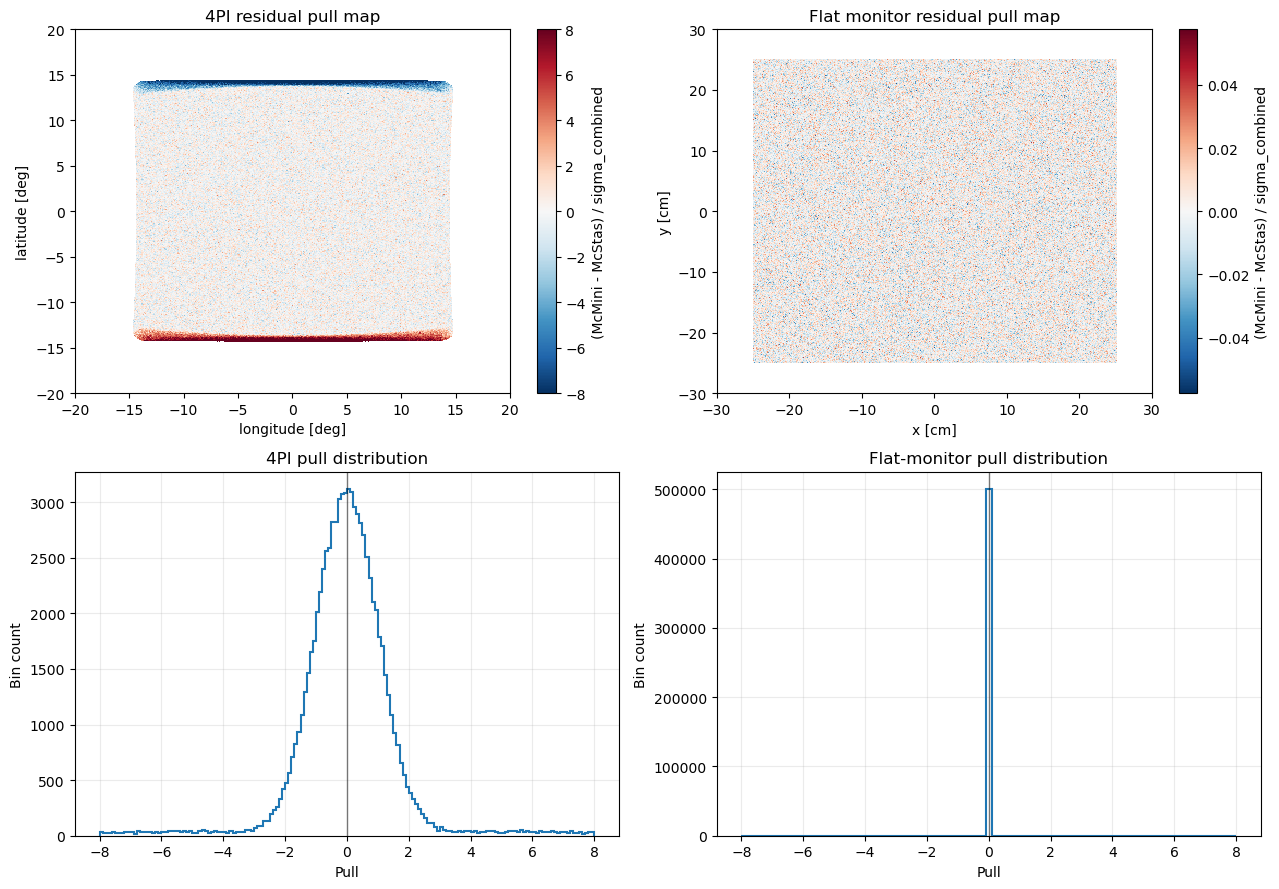

4PI
  Signal threshold:     5.747646e-05
  Bins in test:         83286
  chi^2:               3.303493e+05
  reduced chi^2:       3.966444e+00
  p-value:             0.000000e+00
  mean pull:           3.802294e-03
  pull std:            1.991590e+00
  frac(|pull|>2):      1.054559e-01
  frac(|pull|>3):      5.896549e-02
Flat
  Signal threshold:     5.103642e-06
  Bins in test:         1000000
  chi^2:               1.269871e+02
  reduced chi^2:       1.269871e-04
  p-value:             1.000000e+00
  mean pull:           -2.556089e-04
  pull std:            1.126596e-02
  frac(|pull|>2):      0.000000e+00
  frac(|pull|>3):      0.000000e+00


In [14]:
# Quantify whether the McStas-McMini residuals are consistent with noise only
from scipy.stats import chi2 as chi2_dist

def read_n_history(path):
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.startswith("# n_history="):
                return int(line.split("=", 1)[1].strip())
    raise ValueError(f"Could not find n_history header in {path}")


def load_mcmini_binned(path):
    data = np.loadtxt(path, delimiter=",", comments="#")
    nx = int(np.max(data[:, 0])) + 1
    ny = int(np.max(data[:, 1])) + 1
    I = data[:, 2].reshape((ny, nx))
    if data.shape[1] >= 4 and np.all(np.isfinite(data[:, 3])):
        sigma = data[:, 3].reshape((ny, nx))
    else:
        n_history = read_n_history(path)
        sigma = np.sqrt(np.maximum(I * n_history, 0.0)) / n_history
    return I, sigma


def load_mcstas_monitor(path):
    mon = ms.load_data(str(path))[0]
    I = np.array(mon.Intensity, copy=True)
    sigma = np.array(mon.Error, copy=True)
    meta = mon.metadata
    if I.shape == (meta.dimension[0], meta.dimension[1]):
        I = I.T
        sigma = sigma.T
    return I, sigma, meta


def residual_noise_test(mcmini_I, mcmini_sigma, mcstas_I, mcstas_sigma, signal_fraction=0.05):
    reference = 0.5 * (mcmini_I + mcstas_I)
    signal_threshold = signal_fraction * np.nanmax(reference)
    mask = reference > signal_threshold

    residual = mcmini_I - mcstas_I
    sigma_combined = np.sqrt(mcmini_sigma**2 + mcstas_sigma**2)
    pull = np.full_like(residual, np.nan, dtype=float)
    valid = mask & np.isfinite(residual) & np.isfinite(sigma_combined) & (sigma_combined > 0)
    pull[valid] = residual[valid] / sigma_combined[valid]

    n_valid = int(np.sum(valid))
    chi2 = float(np.nansum(pull[valid]**2))
    chi2_red = chi2 / n_valid if n_valid > 0 else np.nan
    p_value = float(chi2_dist.sf(chi2, n_valid)) if n_valid > 0 else np.nan
    mean_pull = float(np.nanmean(pull[valid])) if n_valid > 0 else np.nan
    std_pull = float(np.nanstd(pull[valid])) if n_valid > 0 else np.nan
    frac_pull_gt_2 = float(np.mean(np.abs(pull[valid]) > 2.0)) if n_valid > 0 else np.nan
    frac_pull_gt_3 = float(np.mean(np.abs(pull[valid]) > 3.0)) if n_valid > 0 else np.nan

    return {
        "mask": mask,
        "residual": residual,
        "pull": pull,
        "signal_threshold": signal_threshold,
        "n_valid": n_valid,
        "chi2": chi2,
        "chi2_red": chi2_red,
        "p_value": p_value,
        "mean_pull": mean_pull,
        "std_pull": std_pull,
        "frac_pull_gt_2": frac_pull_gt_2,
        "frac_pull_gt_3": frac_pull_gt_3,
    }

# 4PI monitor
mcstas_4pi_I, mcstas_4pi_sigma, mcstas_4pi_meta = load_mcstas_monitor(
    Path("/Users/christian/Documents/Study/bachelor_project/mcmini_verification/monitor_sphere_validation/source_to_4pi_monitor")
)
mcmini_4pi_I, mcmini_4pi_sigma = load_mcmini_binned(
    Path("/Users/christian/Documents/Study/bachelor_project/mcmini_verification/monitor_sphere_validation/source_to_4pi_monitor.csv")
)

test_4pi = residual_noise_test(mcmini_4pi_I, mcmini_4pi_sigma, mcstas_4pi_I, mcstas_4pi_sigma)

# flat monitor
mcstas_flat_I, mcstas_flat_sigma, mcstas_flat_meta = load_mcstas_monitor(
    Path("/Users/christian/Documents/Study/bachelor_project/mcmini_verification/source_simple_verification/source_to_flat_monitor")
)
mcmini_flat_I, mcmini_flat_sigma = load_mcmini_binned(
    Path("/Users/christian/Documents/Study/bachelor_project/mcmini_verification/source_simple_verification/source_to_flat_monitor.csv")
)

test_flat = residual_noise_test(mcmini_flat_I, mcmini_flat_sigma, mcstas_flat_I, mcstas_flat_sigma)

fig, axs = plt.subplots(2, 2, figsize=(13, 9))

pull_absmax_4pi = min(np.nanmax(np.abs(test_4pi["pull"])), 8.0)
im0 = axs[0, 0].imshow(
    test_4pi["pull"],
    origin="lower",
    extent=mcstas_4pi_meta.limits,
    aspect="auto",
    interpolation="nearest",
    cmap="RdBu_r",
    vmin=-pull_absmax_4pi,
    vmax=pull_absmax_4pi,
)
axs[0, 0].set_xlim(-20, 20)
axs[0, 0].set_ylim(-20, 20)
axs[0, 0].set_xlabel("longitude [deg]")
axs[0, 0].set_ylabel("latitude [deg]")
axs[0, 0].set_title("4PI residual pull map")
fig.colorbar(im0, ax=axs[0, 0], label="(McMini - McStas) / sigma_combined")

pull_absmax_flat = min(np.nanmax(np.abs(test_flat["pull"])), 8.0)
im1 = axs[0, 1].imshow(
    test_flat["pull"],
    origin="lower",
    extent=mcstas_flat_meta.limits,
    aspect="auto",
    interpolation="nearest",
    cmap="RdBu_r",
    vmin=-pull_absmax_flat,
    vmax=pull_absmax_flat,
)
axs[0, 1].set_xlim(-30, 30)
axs[0, 1].set_ylim(-30, 30)
axs[0, 1].set_xlabel("x [cm]")
axs[0, 1].set_ylabel("y [cm]")
axs[0, 1].set_title("Flat monitor residual pull map")
fig.colorbar(im1, ax=axs[0, 1], label="(McMini - McStas) / sigma_combined")

bins = np.linspace(-8, 8, 161)
axs[1, 0].hist(test_4pi["pull"][np.isfinite(test_4pi["pull"])], bins=bins, histtype="step", lw=1.5)
axs[1, 0].axvline(0.0, color="k", lw=1.0, alpha=0.5)
axs[1, 0].set_xlabel("Pull")
axs[1, 0].set_ylabel("Bin count")
axs[1, 0].set_title("4PI pull distribution")
axs[1, 0].grid(alpha=0.25)

axs[1, 1].hist(test_flat["pull"][np.isfinite(test_flat["pull"])], bins=bins, histtype="step", lw=1.5)
axs[1, 1].axvline(0.0, color="k", lw=1.0, alpha=0.5)
axs[1, 1].set_xlabel("Pull")
axs[1, 1].set_ylabel("Bin count")
axs[1, 1].set_title("Flat-monitor pull distribution")
axs[1, 1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

for label, result in [("4PI", test_4pi), ("Flat", test_flat)]:
    print(label)
    print(f"  Signal threshold:     {result['signal_threshold']:.6e}")
    print(f"  Bins in test:         {result['n_valid']}")
    print(f"  chi^2:               {result['chi2']:.6e}")
    print(f"  reduced chi^2:       {result['chi2_red']:.6e}")
    print(f"  p-value:             {result['p_value']:.6e}")
    print(f"  mean pull:           {result['mean_pull']:.6e}")
    print(f"  pull std:            {result['std_pull']:.6e}")
    print(f"  frac(|pull|>2):      {result['frac_pull_gt_2']:.6e}")
    print(f"  frac(|pull|>3):      {result['frac_pull_gt_3']:.6e}")

